In [3]:
# 1. & 2. Load the dataset (using the standard URL for the Boston Housing data)
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<unknown>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<ipython-input-3-99738e0fa72f>:3: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
<ipython-input-3-99738e0fa72f>:3: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


<class 'NameError'>: name 'pd' is not defined

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df=pd.read_csv("boston.csv")

In [6]:
df.shape

(506, 14)

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
# 1. Define Features (X) and Target (y)
# Assuming 'MEDV' or 'PRICE' is your target column name
X = df.drop('MEDV', axis=1) 
y = df['MEDV']

In [16]:
# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# 3. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# 4. Make Predictions
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [22]:
# 5. Evaluate the Model (The Pro Way)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")
'''# Training Metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Testing Metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train: MSE = {train_mse:.2f}, R2 = {train_r2:.2f}")
print(f"Test:  MSE = {test_mse:.2f}, R2 = {test_r2:.2f}")'''

Mean Squared Error: 24.29
R^2 Score: 0.67


'# Training Metrics\ntrain_mse = mean_squared_error(y_train, y_train_pred)\ntrain_r2 = r2_score(y_train, y_train_pred)\n\n# Testing Metrics\ntest_mse = mean_squared_error(y_test, y_test_pred)\ntest_r2 = r2_score(y_test, y_test_pred)\n\nprint(f"Train: MSE = {train_mse:.2f}, R2 = {train_r2:.2f}")\nprint(f"Test:  MSE = {test_mse:.2f}, R2 = {test_r2:.2f}")'

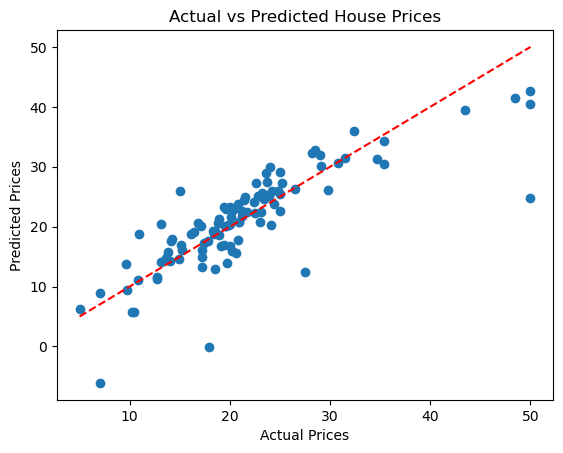

In [20]:
# 6. Visualize the Results
#plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [14]:
# 1. Create a list of 13 values representing one house
# (Example values for: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT)
new_house_data = [[0.1, 10.0, 5.0, 0, 0.4, 6.5, 35, 4.0, 1, 250, 15, 390, 10]]

# 2. Use the model to predict the price
predicted_price = model.predict(new_house_data)

# 3. Print the result (using [0] because predict returns a list)
print(f"The predicted house price is: ${predicted_price[0]:.2f}")

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The predicted house price is: $30.30


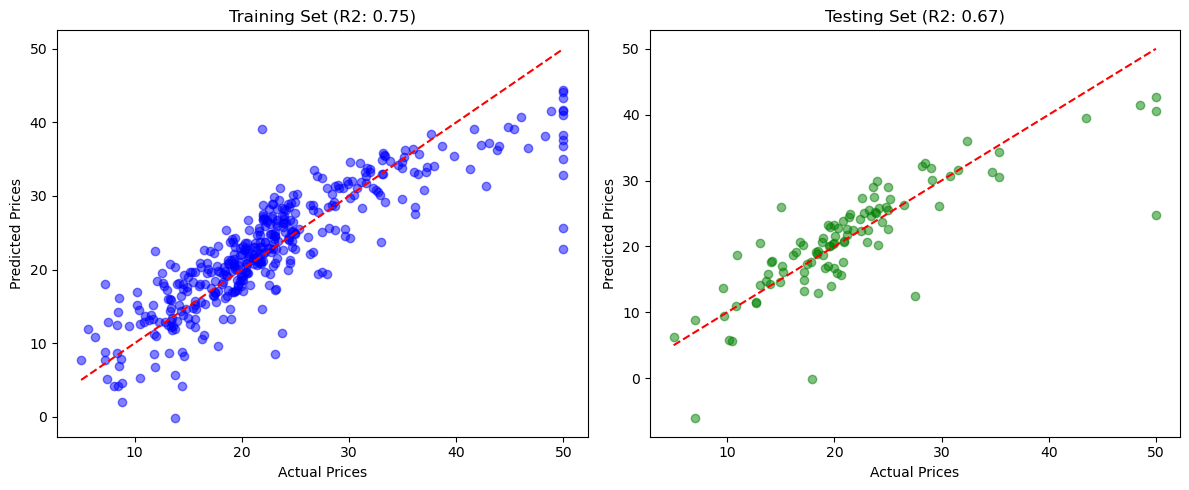

In [37]:
# Create a figure with two subplots (1 row, 2 columns)
plt.figure(figsize=(12, 5))

# 1. Plot Training Results
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.title(f'Training Set (R2: {train_r2:.2f})')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# 2. Plot Testing Results
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Testing Set (R2: {test_r2:.2f})')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.tight_layout()
plt.show()